In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [8]:
df = pd.read_excel("/content/OnlineRetail.xlsx", engine='openpyxl')

In [9]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [10]:
print(f"Row:- {df.shape[0]}")
print(f"Column:- {df.shape[1]}")

Row:- 541909
Column:- 8


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [12]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [13]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,float64
Country,object


In [14]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [15]:
df.duplicated().sum()

np.int64(5268)

In [16]:
df.drop_duplicates(inplace=True)

In [20]:
# after removing duplicates

df.shape

(536641, 8)

In [17]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [18]:
df.tail()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## **Basic cleaning**

In [21]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# EDA

## 1. What are the Top 10 Best-Selling Products?

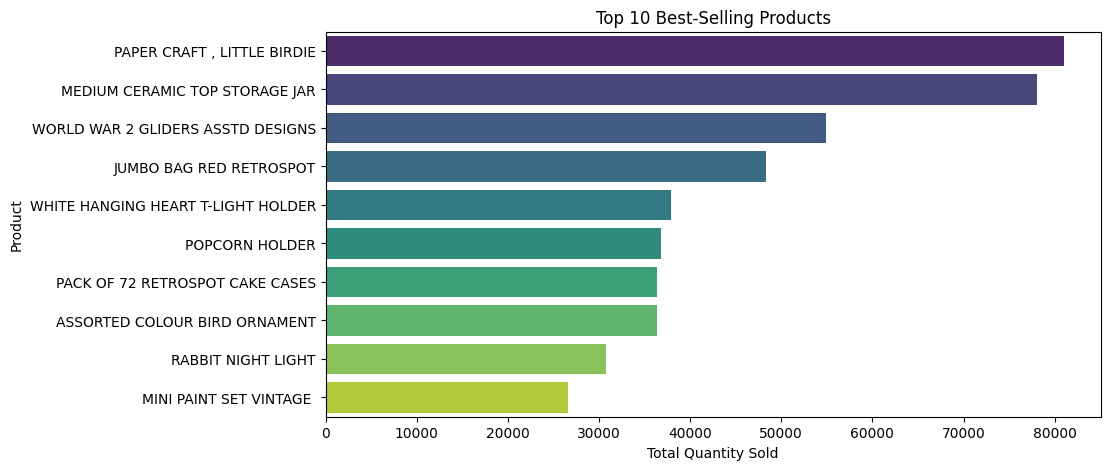

In [22]:
plt.figure(figsize=(10,5))
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, palette="viridis")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")
plt.show()


## 2. Which Countries Generate the Highest Revenue?

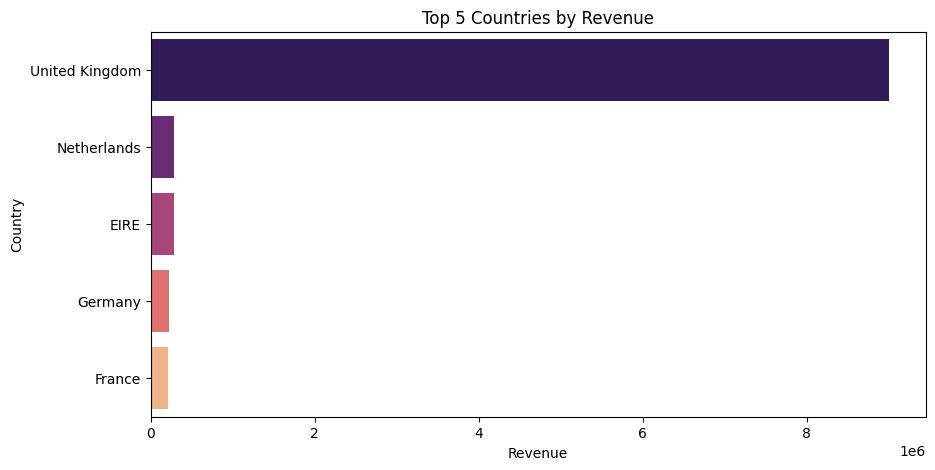

In [24]:
plt.figure(figsize=(10,5))
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="magma")
plt.title("Top 5 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")
plt.show()


## 3. Monthly Revenue Trend Is the Business Growing?

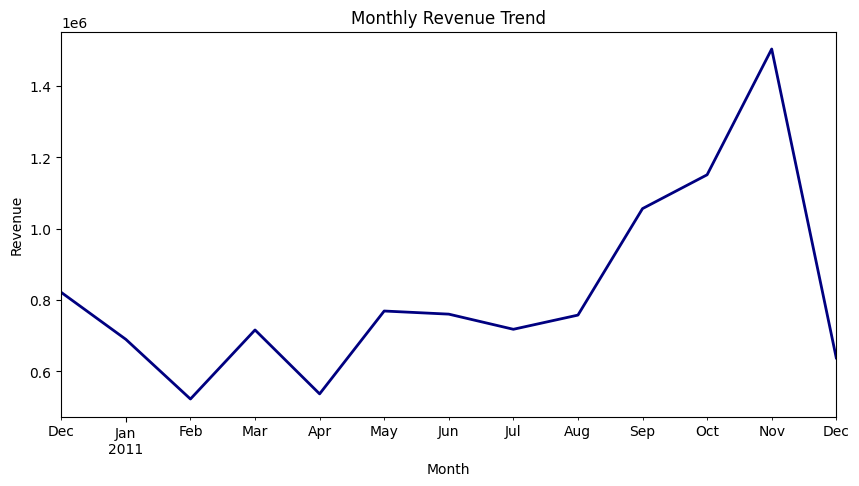

In [25]:
monthly_sales = df.resample('M', on='InvoiceDate')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(color='navy', linewidth=2)
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()


## 4. What is the Distribution of Order Quantities?

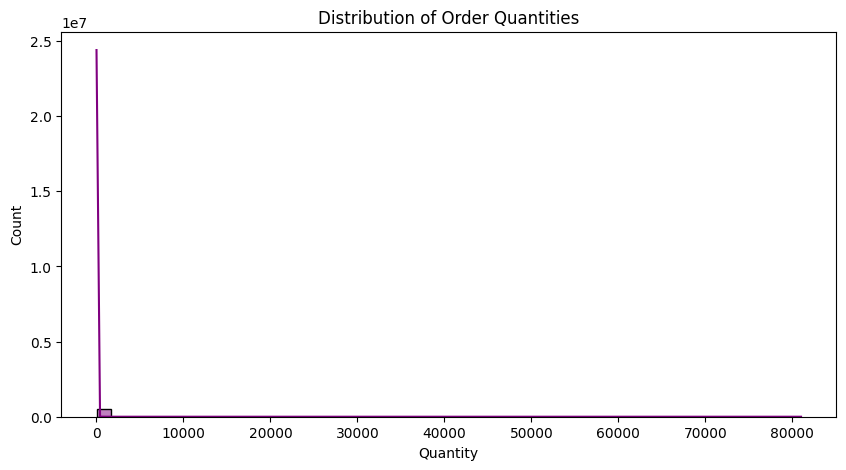

In [26]:
plt.figure(figsize=(10,5))
sns.histplot(df['Quantity'], bins=50, kde=True, color='purple')
plt.title("Distribution of Order Quantities")
plt.xlabel("Quantity")
plt.show()


## 5. How Does Unit Price Vary Across Products?

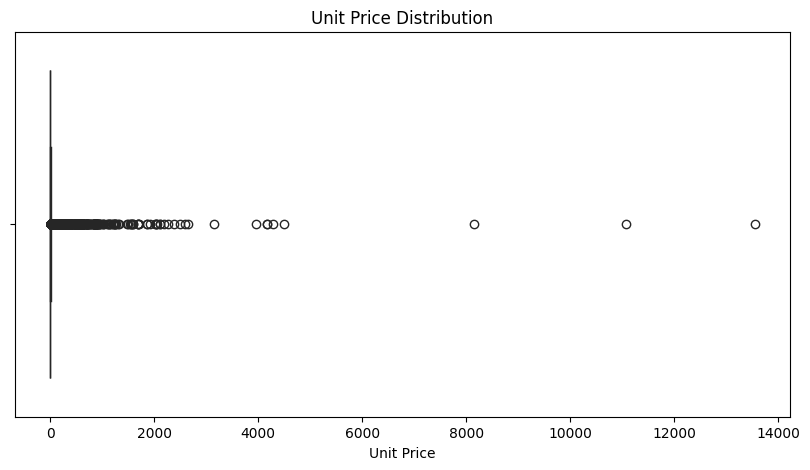

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['UnitPrice'], color='teal')
plt.title("Unit Price Distribution")
plt.xlabel("Unit Price")
plt.show()


## 6. Which Customers Contribute the Most Revenue? (Top 10)

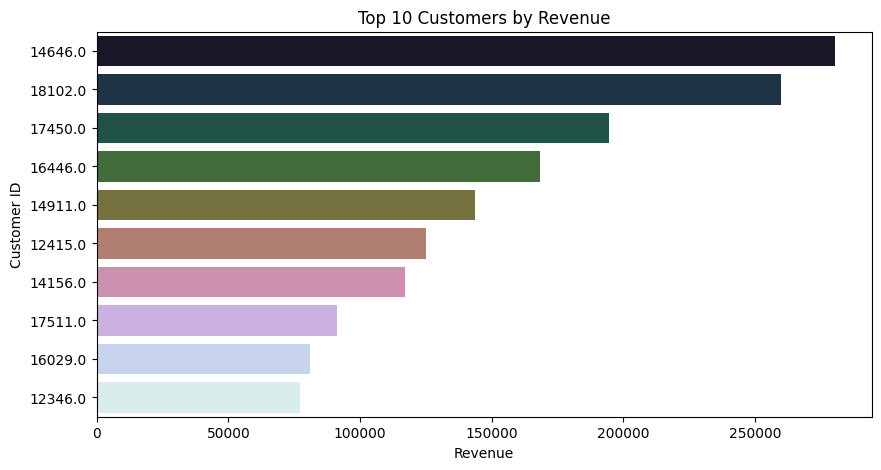

In [28]:
plt.figure(figsize=(10,5))
top_customers = df.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_customers.values, y=top_customers.index.astype(str), palette="cubehelix")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")
plt.show()


## 7. Daily Sales Trend – Are There Seasonal Patterns?

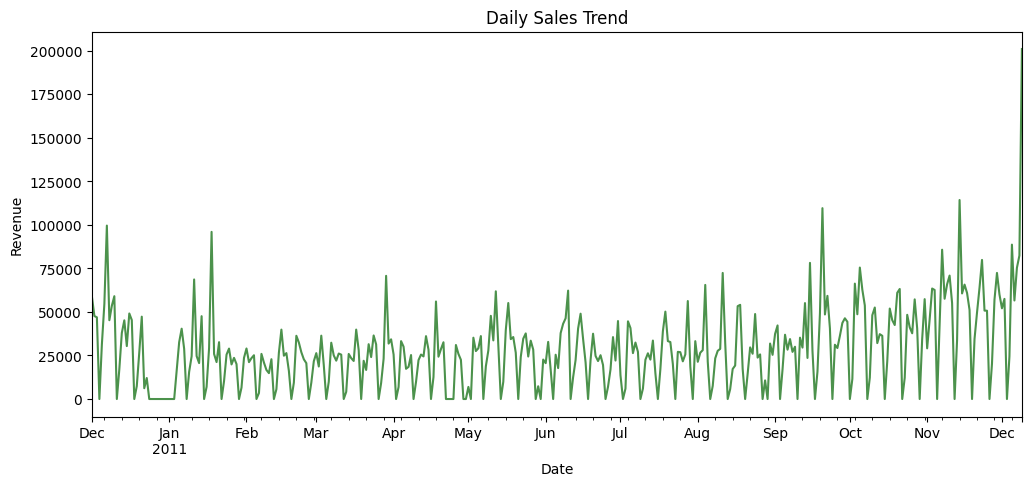

In [29]:
daily_sales = df.resample('D', on='InvoiceDate')['TotalPrice'].sum()
plt.figure(figsize=(12,5))
daily_sales.plot(color='darkgreen', alpha=0.7)
plt.title("Daily Sales Trend")
plt.ylabel("Revenue")
plt.xlabel("Date")
plt.show()


## 8. What is the Relationship Between Unit Price and Quantity Sold?

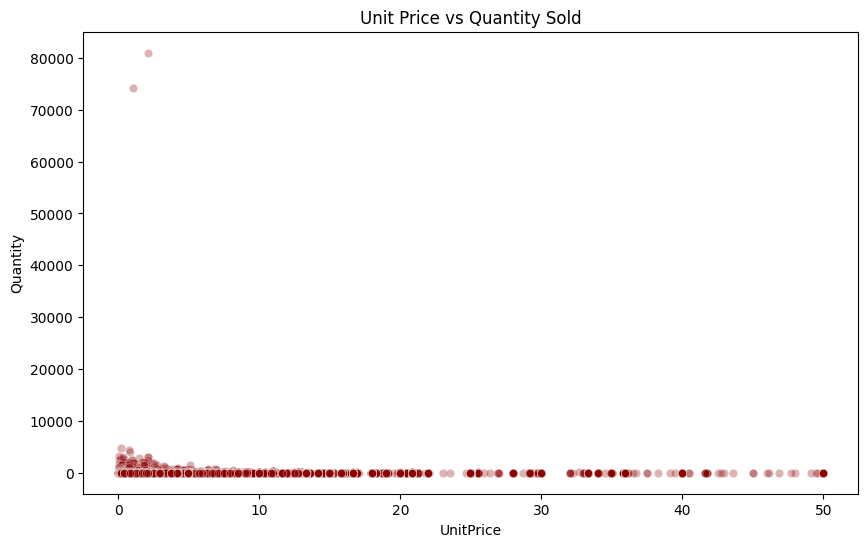

In [30]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='UnitPrice',
    y='Quantity',
    data=df[df['UnitPrice'] < 50],
    alpha=0.3,
    color='darkred'
)
plt.title("Unit Price vs Quantity Sold")
plt.show()


## 9. What Percentage of Sales Comes from Each Country?

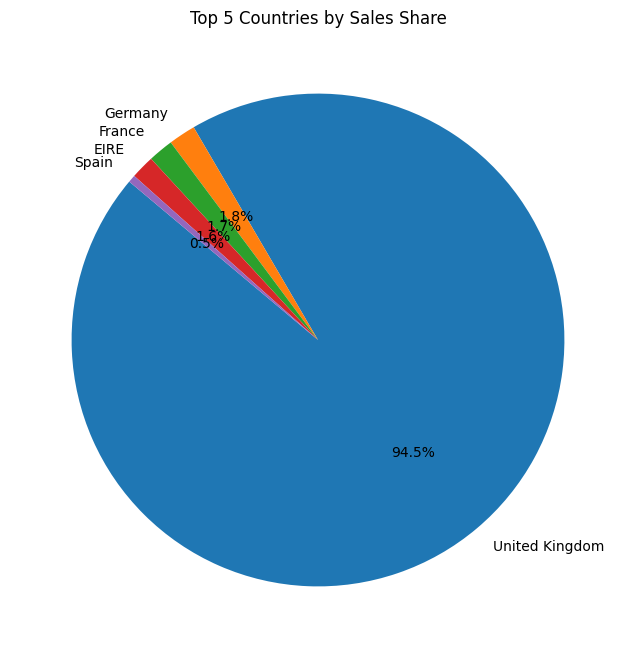

In [31]:
country_share = df['Country'].value_counts().head(5)

plt.figure(figsize=(8,8))
plt.pie(
    country_share,
    labels=country_share.index,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Top 5 Countries by Sales Share")
plt.show()


## 10. What Are the Peak Sales Hours of the Day?

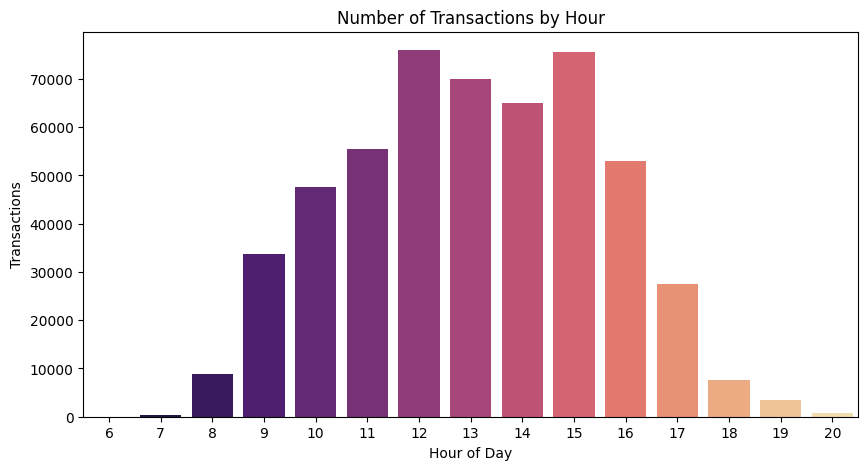

In [33]:
df['Hour'] = df['InvoiceDate'].dt.hour

plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=df, palette="magma")
plt.title("Number of Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")
plt.show()
